## 1. Import các thư viện cần thiết

In [2]:
import pandas as pd
import numpy as np
import re
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM, 
    GlobalMaxPooling1D, GlobalAveragePooling1D, 
    Dense, Dropout, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight

## 1. TIỀN XỬ LÝ DỮ LIỆU

In [5]:
def clean_html(text):
    """Loại bỏ HTML tags"""
    if pd.isna(text):
        return ""
    soup = BeautifulSoup(str(text), "html.parser")
    return soup.get_text()

def preprocess_text(text):
    # Loại HTML
    text = clean_html(text)
    # Chuyển về lowercase
    text = text.lower()
    # Loại bỏ URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Loại bỏ email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Giữ lại chữ cái, số và khoảng trắng
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    # Loại bỏ khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip() 
    return text

def load_and_preprocess_enron(file_path):
    df = pd.read_csv(file_path) 
    # Kết hợp Subject + Body
    df['text'] = df['Subject'].fillna('') + ' ' + df['Message'].fillna('')  
    # Tiền xử lý
    df['cleaned_text'] = df['text'].apply(preprocess_text)
    # Encode label: spam=1, ham=0
    df['label'] = df['Spam/Ham'].map({'spam': 1, 'ham': 0})
    return df[['cleaned_text', 'label']]

## 2. PHÂN TÍCH EXPLORATORY DATA ANALYSIS

In [8]:
def analyze_dataset(df):
    """Phân tích dataset"""
    print("=" * 60)
    print("📊 PHÂN TÍCH DATASET")
    print("=" * 60)
    # 1. Số lượng mẫu
    print(f"\nTổng số mẫu: {len(df)}")
    print(f"Số lượng theo lớp:\n{df['label'].value_counts()}")
    print(f"Tỷ lệ spam/ham: {df['label'].value_counts(normalize=True)}")
    # 2. Độ dài chuỗi
    df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))
    print(f"\nĐộ dài trung bình: {df['text_length'].mean():.2f} từ")
    print(f"Độ dài min/max: {df['text_length'].min()} / {df['text_length'].max()} từ")
    print(f"Độ dài median: {df['text_length'].median():.2f} từ")
    # 3. Phân bố độ dài
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    df['text_length'].hist(bins=50)
    plt.xlabel('Số từ')
    plt.ylabel('Số lượng')
    plt.title('Phân bố độ dài email')
    plt.axvline(256, color='r', linestyle='--', label='Max length = 256')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    df.groupby('label')['text_length'].hist(bins=50, alpha=0.5)
    plt.xlabel('Số từ')
    plt.ylabel('Số lượng')
    plt.title('Độ dài theo lớp')
    plt.legend(['Ham', 'Spam'])
    
    plt.tight_layout()
    plt.savefig('data_analysis.png', dpi=300, bbox_inches='tight')
    print("\nĐã lưu biểu đồ phân tích vào 'data_analysis.png'")
    # 4. Class imbalance
    imbalance_ratio = df['label'].value_counts()[0] / df['label'].value_counts()[1]
    print(f"\nĐộ mất cân bằng: {imbalance_ratio:.2f}:1 (ham:spam)")
    if imbalance_ratio > 3:
        print("Dataset bị mất cân bằng nghiêm trọng!")
        print("Khuyến nghị: Sử dụng class weights")
    
    return df

## 3. CHUẨN BỊ DỮ LIỆU CHO TRAINING

In [11]:
def prepare_data(df, max_len=256, max_words=10000):
    """Tokenize và padding"""
    # Tokenization
    tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
    tokenizer.fit_on_texts(df['cleaned_text'])
    # Convert to sequences
    sequences = tokenizer.texts_to_sequences(df['cleaned_text'])
    # Padding
    X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
    y = df['label'].values
    
    print(f"\nVocab size: {len(tokenizer.word_index)}")
    print(f"Shape X: {X.shape}")
    print(f"Shape y: {y.shape}")
    
    return X, y, tokenizer

## 4. BASELINE MODEL: BiLSTM

In [14]:
def build_bilstm_baseline(vocab_size, max_len=256, embedding_dim=128):
    """
    Baseline: BiLSTM + Embedding + Pooling + CE Loss
    """
    input_layer = Input(shape=(max_len,), name='input')
    # Embedding layer
    x = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len,
        name='embedding'
    )(input_layer)
    # BiLSTM
    x = Bidirectional(LSTM(64, return_sequences=True), name='bilstm')(x)
    x = Dropout(0.3)(x)
    # Pooling (Max + Average)
    max_pool = GlobalMaxPooling1D()(x)
    avg_pool = GlobalAveragePooling1D()(x)
    x = Concatenate()([max_pool, avg_pool])
    # Dense layers
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    # Output
    output = Dense(1, activation='sigmoid', name='output')(x)
    
    model = Model(inputs=input_layer, outputs=output, name='BiLSTM_Baseline')
    return model

## 5. TRAINING

In [17]:
def train_model(model, X_train, y_train, X_val, y_val, class_weights=None):
    """Train model với callbacks"""
    # Compile
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
    ]
    # Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )
    return history

## 6. Đánh giá

In [20]:
def evaluate_model(model, X_test, y_test):
    """Đánh giá chi tiết"""
    # Predict
    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba > 0.5).astype(int)
    print("\n" + "=" * 60)
    print("📈 KẾT QUẢ ĐÁNH GIÁ")
    print("=" * 60)
    # Classification Report
    print("\n1. PRECISION / RECALL / F1-SCORE:")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\n2. CONFUSION MATRIX:")
    print(cm)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Ham', 'Spam'], 
                yticklabels=['Ham', 'Spam'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    print("Đã lưu Confusion Matrix vào 'confusion_matrix.png'")
    # PR Curve
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, marker='.')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.grid(True)
    plt.savefig('pr_curve.png', dpi=300, bbox_inches='tight')
    print("Đã lưu PR Curve vào 'pr_curve.png'")
    
    # Recall riêng của Spam
    spam_recall = recall[1] if len(recall) > 1 else recall[-1]
    print(f"\n3. RECALL CỦA SPAM: {spam_recall:.4f}")
    return y_pred, y_pred_proba

## 7. Main

Đang load dataset...


C:\Users\Admin\AppData\Local\Temp\ipykernel_37588\1056433268.py:5: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(str(text), "html.parser")


📊 PHÂN TÍCH DATASET

Tổng số mẫu: 33716
Số lượng theo lớp:
label
1    17171
0    16545
Name: count, dtype: int64
Tỷ lệ spam/ham: label
1    0.509283
0    0.490717
Name: proportion, dtype: float64

Độ dài trung bình: 268.23 từ
Độ dài min/max: 1 / 37137 từ
Độ dài median: 161.00 từ

Đã lưu biểu đồ phân tích vào 'data_analysis.png'

Độ mất cân bằng: 0.96:1 (ham:spam)

Vocab size: 60367
Shape X: (33716, 256)
Shape y: (33716,)

Train: 23614 | Val: 5044 | Test: 5058
Class weights: {0: 1.0188988608905765, 1: 0.9817894561782804}


C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "BiLSTM_Baseline"

...

738/738 ━━━━━━━━━━━━━━━━━━━━ 89s 112ms/step - accuracy: 0.9729 - loss: 0.0857 - precision: 0.9583 - recall: 0.9956 - val_accuracy: 1.0000 - val_loss: 0.0013 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9993 - loss: 0.0040 - precision: 0.9992 - recall: 0.9995

738/738 ━━━━━━━━━━━━━━━━━━━━ 80s 108ms/step - accuracy: 0.9993 - loss: 0.0040 - precision: 0.9992 - recall: 0.9995 - val_accuracy: 1.0000 - val_loss: 7.3062e-04 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 88s 120ms/step - accuracy: 0.9998 - loss: 0.0025 - precision: 0.9995 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 8.2221e-04 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9996 - loss: 0.0030 - precision: 0.9993 - recall: 1.0000

738/738 ━━━━━━━━━━━━━━━━━━━━ 86s 116ms/step - accuracy: 0.9996 - loss: 0.0030 - precision: 0.9993 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 2.8631e-04 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 90s 122ms/step - accuracy: 0.9999 - loss: 0.0016 - precision: 0.9998 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0022 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 6/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9997 - loss: 0.0023 - precision: 0.9995 - recall: 1.0000

738/738 ━━━━━━━━━━━━━━━━━━━━ 84s 114ms/step - accuracy: 0.9997 - loss: 0.0023 - precision: 0.9995 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.0072e-04 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 7/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 99s 134ms/step - accuracy: 0.9999 - loss: 0.0016 - precision: 0.9998 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0015 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 8/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9998 - loss: 0.0021 - precision: 0.9995 - recall: 1.0000

738/738 ━━━━━━━━━━━━━━━━━━━━ 88s 119ms/step - accuracy: 0.9998 - loss: 0.0021 - precision: 0.9995 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 7.9143e-05 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 9/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 110s 150ms/step - accuracy: 0.9998 - loss: 0.0018 - precision: 0.9997 - recall: 0.9998 - val_accuracy: 1.0000 - val_loss: 4.0629e-04 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 10/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 94s 128ms/step - accuracy: 0.9998 - loss: 0.0022 - precision: 0.9996 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 2.0682e-04 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 11/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 115s 155ms/step - accuracy: 0.9998 - loss: 0.0019 - precision: 0.9997 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 5.9497e-04 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 12/30
738/738 ━━━━━━━━━━━━━━━

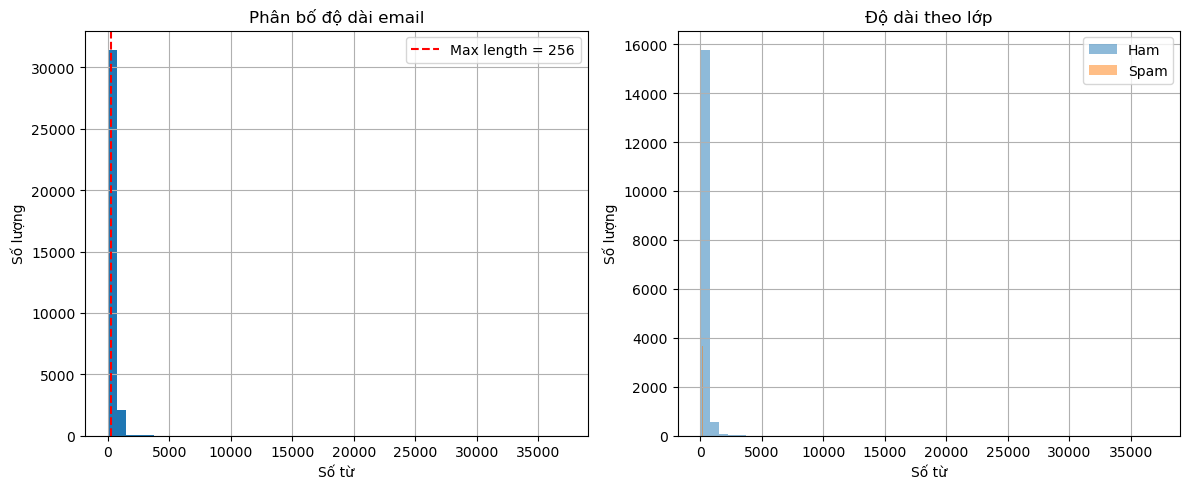

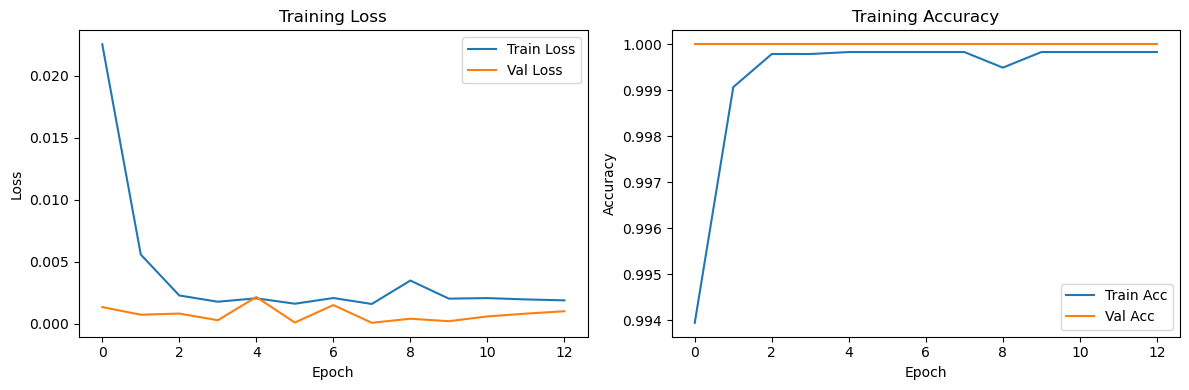

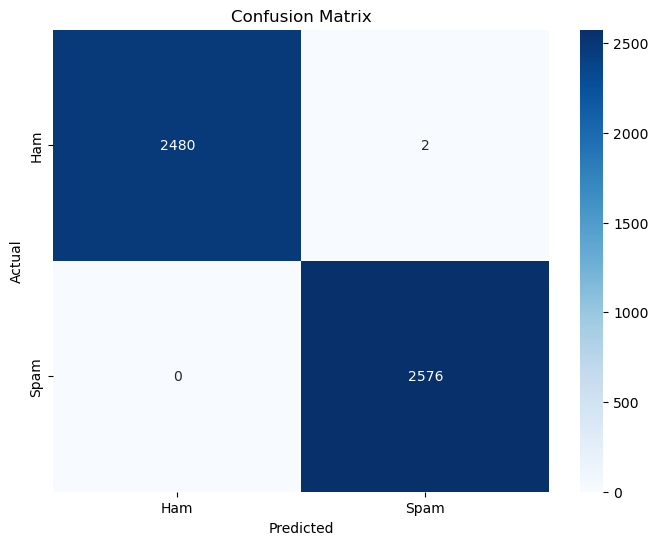

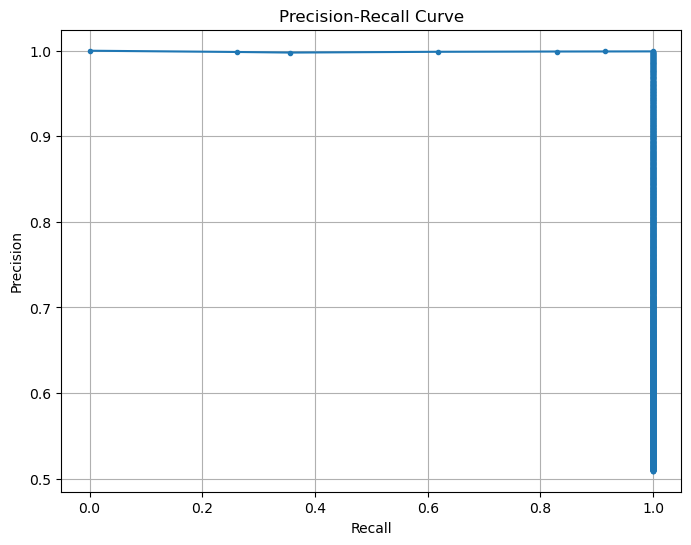

In [23]:
def main():
    # Load data
    print("Đang load dataset...")
    df = load_and_preprocess_enron('enron_spam_data.csv')
    # EDA
    df = analyze_dataset(df)
    # Prepare data
    X, y, tokenizer = prepare_data(df, max_len=256, max_words=10000)
    # Split data
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
    )  # 0.176 * 0.85 ≈ 0.15 → 70/15/15 split
    print(f"\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
    # Compute class weights
    class_weights_array = compute_class_weight(
        'balanced', 
        classes=np.unique(y_train), 
        y=y_train
    )
    class_weights = {0: class_weights_array[0], 1: class_weights_array[1]}
    print(f"Class weights: {class_weights}")
    # Build model
    vocab_size = min(len(tokenizer.word_index) + 1, 10000)
    model = build_bilstm_baseline(vocab_size, max_len=256, embedding_dim=128)
    model.summary()
    # Train
    print("\nBắt đầu training...")
    history = train_model(model, X_train, y_train, X_val, y_val, class_weights)
    # Plot training history
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training Accuracy')
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    # Evaluate
    evaluate_model(model, X_test, y_test)
    
    print("\nHOÀN THÀNH!")

if __name__ == "__main__":
    main()